# Notebook 2 — Training Fixes
### Gradient Autopsy · Phase 2 (part 1)

This notebook heals the training failures from Notebook 1. Starting from the same fragile network, we
apply each fix one at a time and measure it: activations (ReLU/LeakyReLU/SELU), weight initialization
(Xavier/He), batch normalization, optimizers (SGD/Momentum/Adam), and the learning-rate sweep. The
payoff is watching the vanishing-gradient heatmap straighten out.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive"

Mounted at /content/drive


In [3]:
# Restore the cached CIFAR-10 from Drive so common.py doesn't re-download it.
import shutil
shutil.copytree("/content/drive/MyDrive/cifar_data/data", "./data", dirs_exist_ok=True)
print("CIFAR restored from Drive ✓")

CIFAR restored from Drive ✓


In [4]:
%run /content/drive/MyDrive/gradient_autopsy_common.py

# GPU check — warns loudly if you forgot to enable the GPU runtime.
if device.type == "cuda":
    print(f"✅ GPU active: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  NO GPU! Fix: Runtime → Change runtime type → T4 GPU, then re-run these cells.")

[common] Loaded: CONFIG, set_seed, device, loaders, FragileCNN, train_and_instrument, plot_gradient_heatmap, MLP, SmallCNN, train_timed
[common] device=cuda  RESULTS_DIR=./gradient_autopsy_results
✅ GPU active: Tesla T4


## C9 · Activation Sweep — the first fix for the vanishing gradient

The broken heatmap from Notebook 1 was caused primarily by the **sigmoid** activation, whose small,
saturating derivative shrinks the gradient at every layer. Here we hold the architecture fixed and
change only the activation — sigmoid → ReLU → LeakyReLU → SELU — and measure gradient flow for each.

**What to expect.** Sigmoid reproduces the catastrophic vanishing gradient. ReLU, whose derivative is
1 for positive inputs, should dramatically lift the early-layer gradients. LeakyReLU behaves
similarly (and fixes ReLU's "dying" edge case). SELU, which self-normalizes, should give the most
balanced gradient flow of all.

We plot each activation's gradient heatmap and compare the first-to-last-layer gradient ratio — the
smaller the ratio, the healthier the network. This is the controlled-experiment method: one variable
changes, everything else stays identical (same seed, depth, data).

In [5]:
# Sweep the activation function, holding architecture / seed / data fixed.
activations = ["sigmoid", "relu", "leaky_relu", "selu"]
act_results = {}

print("Activation sweep (first-layer vs last-layer gradient — smaller ratio = healthier):\n")
for act in activations:
    set_seed(CONFIG["seed"])
    model = FragileCNN(
        depth=CONFIG["cnn_depth"],
        width=CONFIG["cnn_width"],
        activation=act,        # the ONLY thing changing
        use_bn=False,
        init="default",
    )
    result = train_and_instrument(
        model, small_train_loader, test_loader,
        epochs=CONFIG["sweep_epochs"], lr=0.1, verbose=False,
    )
    act_results[act] = result
    gh = result["grad_history"]
    first, last = gh[-1, 0], gh[-1, -1]
    ratio = last / (first + 1e-12)
    print(f"  {act:12s}: first={first:.2e} | last={last:.2e} | ratio={ratio:,.1f}x | final test_acc={result['test_acc'][-1]:.3f}")

# Save for the synthesis notebook.
for act, result in act_results.items():
    np.save(f"{RESULTS_DIR}/act_{act}_grad_history.npy", result["grad_history"])
print(f"\nSaved activation-sweep gradient histories to {RESULTS_DIR}")

Activation sweep (first-layer vs last-layer gradient — smaller ratio = healthier):

  sigmoid     : first=4.36e-08 | last=2.98e-01 | ratio=6,835,693.1x | final test_acc=0.100
  relu        : first=1.17e-04 | last=1.86e-02 | ratio=159.6x | final test_acc=0.100
  leaky_relu  : first=1.21e-04 | last=1.86e-02 | ratio=154.3x | final test_acc=0.100
  selu        : first=6.94e-01 | last=7.09e-01 | ratio=1.0x | final test_acc=0.267

Saved activation-sweep gradient histories to ./gradient_autopsy_results


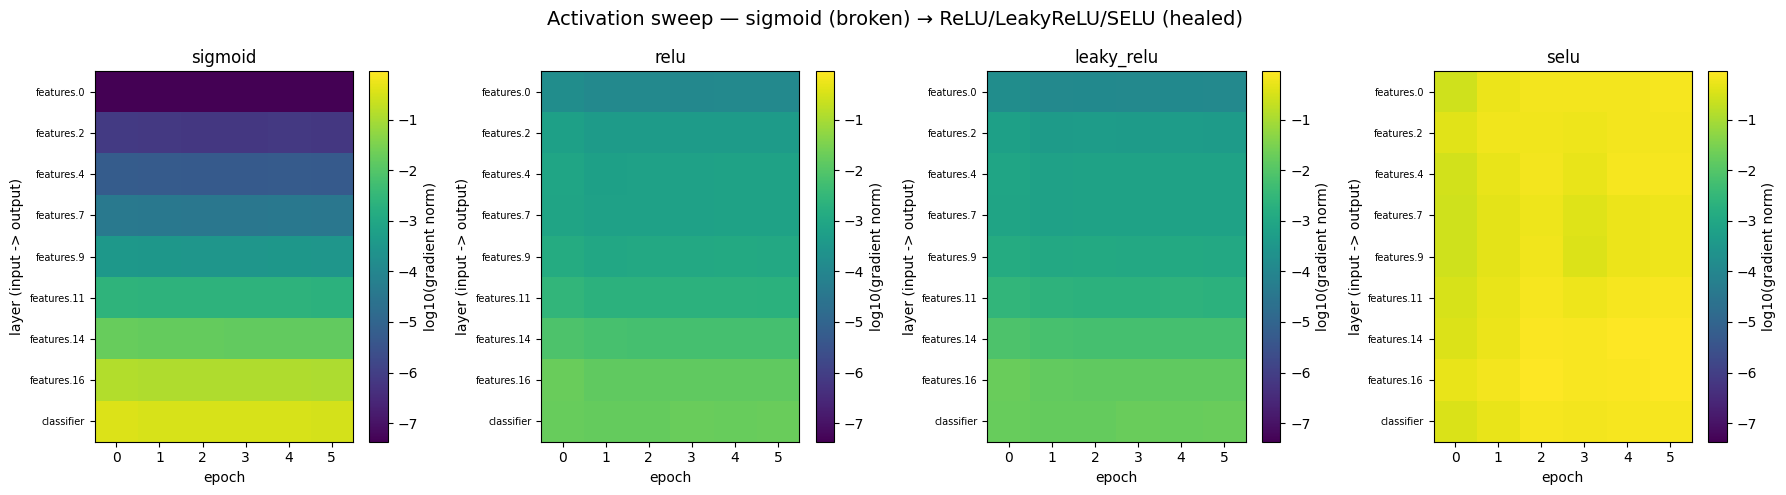

In [6]:
# Plot all four activation heatmaps side by side, on a SHARED color scale for fair comparison.
# Shared vmin/vmax is essential — otherwise each heatmap auto-scales and you can't compare them.
all_logs = [np.log10(r["grad_history"].T + 1e-12) for r in act_results.values()]
vmin = min(a.min() for a in all_logs)
vmax = max(a.max() for a in all_logs)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (act, result) in zip(axes, act_results.items()):
    plot_gradient_heatmap(result, title=act, ax=ax, vmin=vmin, vmax=vmax)
plt.suptitle("Activation sweep — sigmoid (broken) → ReLU/LeakyReLU/SELU (healed)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c9_activation_sweep.png", dpi=120)
plt.show()

## C10 · Initialization Sweep — starting the network in a healthy place

C9 fixed the activation. But even with ReLU, the *scale* of the initial weights determines whether
the signal survives the first forward/backward pass. Here we hold the activation fixed (ReLU) and
change only the initialization: default → Xavier/Glorot → He/Kaiming.

**Why measure at epoch 1.** Initialization is a *starting-condition* effect. Its impact is sharpest
before training has had a chance to adjust the weights, so we measure the gradient at the very first
epoch — later, the difference partly washes out as all schemes adapt.

**What to expect.** Default init leaves a large gradient imbalance even with ReLU. Xavier (designed
for symmetric activations) and He (designed specifically for ReLU, accounting for the fact that ReLU
zeros half its inputs) should both improve the early-layer signal — He most of all for a ReLU network.

In [7]:
# Sweep initialization, holding activation (ReLU) / seed / data fixed.
# Measure at EPOCH 1 — init is a starting-condition effect.
inits = ["default", "xavier", "he"]
init_results = {}

print("Initialization sweep (ReLU fixed) — epoch-1 gradient (smaller ratio = healthier start):\n")
for init in inits:
    set_seed(CONFIG["seed"])
    model = FragileCNN(
        depth=CONFIG["cnn_depth"],
        width=CONFIG["cnn_width"],
        activation="relu",     # activation held fixed
        use_bn=False,
        init=init,             # the ONLY thing changing
    )
    result = train_and_instrument(
        model, small_train_loader, test_loader,
        epochs=CONFIG["sweep_epochs"], lr=0.1, verbose=False,
    )
    init_results[init] = result
    gh = result["grad_history"]
    # epoch-1 (index 0) values — the starting-condition signal
    first, last = gh[0, 0], gh[0, -1]
    ratio = last / (first + 1e-12)
    print(f"  {init:9s}: epoch1 first={first:.2e} | last={last:.2e} | ratio={ratio:,.1f}x | final test_acc={result['test_acc'][-1]:.3f}")

# Save for synthesis.
for init, result in init_results.items():
    np.save(f"{RESULTS_DIR}/init_{init}_grad_history.npy", result["grad_history"])
print(f"\nSaved init-sweep histories to {RESULTS_DIR}")

Initialization sweep (ReLU fixed) — epoch-1 gradient (smaller ratio = healthier start):

  default  : epoch1 first=1.69e-04 | last=1.83e-02 | ratio=108.1x | final test_acc=0.100
  xavier   : epoch1 first=2.76e-02 | last=2.49e-02 | ratio=0.9x | final test_acc=0.199
  he       : epoch1 first=1.13e-01 | last=1.93e-01 | ratio=1.7x | final test_acc=0.231

Saved init-sweep histories to ./gradient_autopsy_results


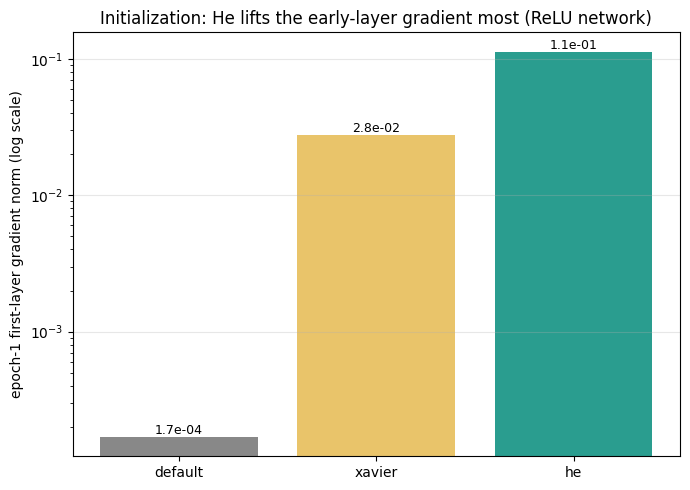

In [8]:
# Compare the epoch-1 first-layer gradient across init schemes — the clearest single number.
first_layer_grads = [init_results[init]["grad_history"][0, 0] for init in inits]

plt.figure(figsize=(7, 5))
bars = plt.bar(inits, first_layer_grads, color=["#888", "#e9c46a", "#2a9d8f"])
plt.yscale("log")   # log scale — the values span orders of magnitude
plt.ylabel("epoch-1 first-layer gradient norm (log scale)")
plt.title("Initialization: He lifts the early-layer gradient most (ReLU network)")
plt.grid(True, axis="y", alpha=0.3)
for bar, val in zip(bars, first_layer_grads):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{val:.1e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c10_init_sweep.png", dpi=120)
plt.show()

## C11 · Batch Normalization — keeping activations healthy during training

Activation (C9) and initialization (C10) fix the *starting* conditions. But as training proceeds and
weights change, each layer's input distribution drifts, and activations can slide back into saturated
regions. **Batch normalization** counteracts this by re-standardizing each layer's activations per
mini-batch, keeping them in a healthy range throughout training.

**Two things this cell demonstrates:**

1. **BN on vs off** — we add BatchNorm to the *sigmoid* network (the worst case) and show it rescues
   the gradient flow dramatically, even without changing the activation.

2. **The train/eval buffer behavior** (the detail most people skip) — BatchNorm maintains internal
   *running statistics* (`running_mean`, `running_var`) that update during `train()` mode and are
   used, frozen, during `eval()` mode. We print these buffers to prove BN behaves differently in the
   two modes — which is exactly why `model.train()` / `model.eval()` matter.

BatchNorm on vs off (sigmoid network — the worst-case activation):

  BN OFF: first=4.36e-08 | last=2.98e-01 | ratio=6,836,190.7x
  BN ON : first=3.42e-01 | last=3.48e-01 | ratio=1.0x


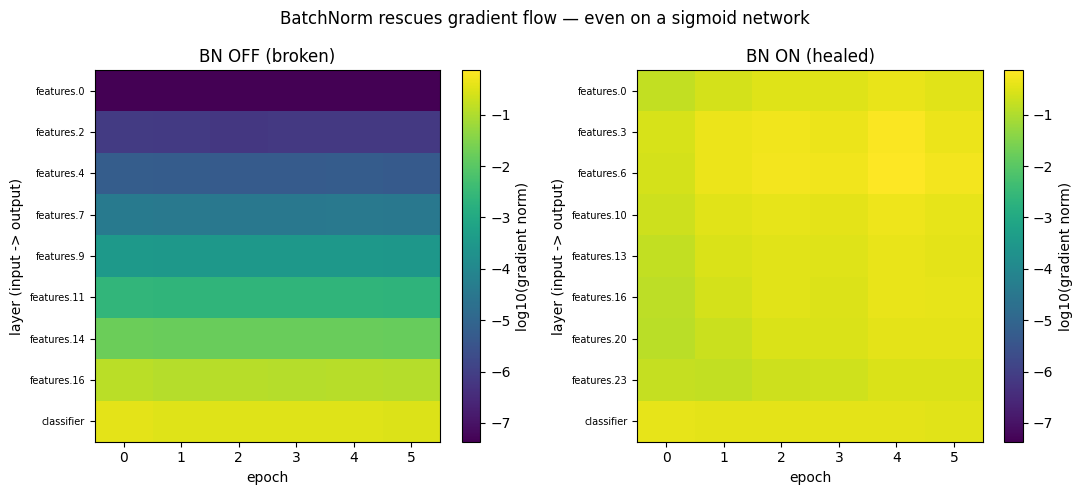

In [9]:
# BatchNorm on vs off, on the SIGMOID network (the hardest case).
print("BatchNorm on vs off (sigmoid network — the worst-case activation):\n")
bn_results = {}
for use_bn in [False, True]:
    set_seed(CONFIG["seed"])
    model = FragileCNN(
        depth=CONFIG["cnn_depth"],
        width=CONFIG["cnn_width"],
        activation="sigmoid",   # deliberately the worst activation
        use_bn=use_bn,          # the ONLY thing changing
        init="default",
    )
    result = train_and_instrument(
        model, small_train_loader, test_loader,
        epochs=CONFIG["sweep_epochs"], lr=0.1, verbose=False,
    )
    bn_results[use_bn] = result
    gh = result["grad_history"]
    ratio = gh[-1, -1] / (gh[-1, 0] + 1e-12)
    label = "BN ON " if use_bn else "BN OFF"
    print(f"  {label}: first={gh[-1,0]:.2e} | last={gh[-1,-1]:.2e} | ratio={ratio:,.1f}x")

np.save(f"{RESULTS_DIR}/bn_off_grad_history.npy", bn_results[False]["grad_history"])
np.save(f"{RESULTS_DIR}/bn_on_grad_history.npy",  bn_results[True]["grad_history"])

# Side-by-side heatmaps on a shared color scale.
logs = [np.log10(bn_results[b]["grad_history"].T + 1e-12) for b in [False, True]]
vmin, vmax = min(a.min() for a in logs), max(a.max() for a in logs)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_gradient_heatmap(bn_results[False], title="BN OFF (broken)", ax=axes[0], vmin=vmin, vmax=vmax)
plot_gradient_heatmap(bn_results[True],  title="BN ON (healed)",  ax=axes[1], vmin=vmin, vmax=vmax)
plt.suptitle("BatchNorm rescues gradient flow — even on a sigmoid network")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c11_batchnorm.png", dpi=120)
plt.show()

In [10]:
# --- The detail most people skip: BatchNorm behaves differently in train vs eval ---
set_seed(CONFIG["seed"])
demo_model = FragileCNN(depth=CONFIG["cnn_depth"], activation="relu", use_bn=True, init="he").to(device)

# Grab the first BatchNorm layer so we can inspect its running statistics.
first_bn = [m for m in demo_model.modules() if isinstance(m, nn.BatchNorm2d)][0]

print("BatchNorm running_mean of the first BN layer (first 5 channels):\n")
print("  At initialization (all zeros):")
print("   ", [round(v, 4) for v in first_bn.running_mean[:5].tolist()])

# Train a few steps in TRAIN mode — the running stats update.
demo_model.train()
optimizer = torch.optim.SGD(demo_model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()
for i, (X, y) in enumerate(small_train_loader):
    X, y = X.to(device), y.to(device)
    optimizer.zero_grad()
    criterion(demo_model(X), y).backward()
    optimizer.step()
    if i >= 5:
        break

print("\n  After a few TRAIN-mode steps (running_mean has updated from data):")
print("   ", [round(v, 4) for v in first_bn.running_mean[:5].tolist()])

# Now switch to EVAL mode and show these frozen buffers are what BN will use.
demo_model.eval()
print("\n  In EVAL mode, BN uses these FROZEN running stats (not the batch's own stats).")
print("  This is why model.train() vs model.eval() matters — same input, different behavior.")

# Concrete proof: same input, different output in train vs eval mode.
sample = next(iter(test_loader))[0][:8].to(device)
demo_model.train(); out_train = demo_model(sample)
demo_model.eval();  out_eval  = demo_model(sample)
diff = (out_train - out_eval).abs().mean().item()
print(f"\n  Mean |output difference| between train and eval mode on the same input: {diff:.5f}")
print("  (non-zero => BN genuinely behaves differently in the two modes)")

BatchNorm running_mean of the first BN layer (first 5 channels):

  At initialization (all zeros):
    [0.0, 0.0, 0.0, 0.0, 0.0]

  After a few TRAIN-mode steps (running_mean has updated from data):
    [-0.005, 0.0036, -0.0008, -0.0041, 0.0196]

  In EVAL mode, BN uses these FROZEN running stats (not the batch's own stats).
  This is why model.train() vs model.eval() matters — same input, different behavior.

  Mean |output difference| between train and eval mode on the same input: 0.23705
  (non-zero => BN genuinely behaves differently in the two modes)


## C12 · Optimizers — hand-rolling the update rule

An optimizer is just the rule that turns gradients into weight updates. In Notebook 1 we wrote plain
SGD by hand (`p -= lr * p.grad`). Here we implement two optimizers **from scratch** to understand
them mechanically, then compare against library Adam:

- **SGD** — step opposite the gradient. The baseline.
- **SGD + Momentum** — maintain a running "velocity" of past gradients (`v = β·v + grad`), then step
  along the velocity. This carries the update through flat regions and damps oscillation.
- **Adam** (from `torch.optim`) — combines momentum with per-parameter adaptive learning rates.

Implementing SGD and Momentum by hand makes the difference concrete: Momentum is literally SGD plus
one extra line that accumulates velocity. We train the *healed* network (ReLU + He + BN, from C9–C11)
so the comparison is about convergence speed, not gradient survival.

In [11]:
def train_with_optimizer(kind, epochs=None, lr=0.1, momentum=0.9, log_every=2):
    """Train the healed network with a hand-rolled or library optimizer.
    kind: 'sgd' | 'momentum' (both hand-written) | 'adam' (library)."""
    if epochs is None:
        epochs = CONFIG["sweep_epochs"]

    set_seed(CONFIG["seed"])
    model = FragileCNN(depth=CONFIG["cnn_depth"], width=CONFIG["cnn_width"],
                       activation="relu", use_bn=True, init="he").to(device)
    criterion = nn.CrossEntropyLoss()

    # For hand-rolled momentum: one velocity buffer per parameter, initialized to zero.
    velocity = {id(p): torch.zeros_like(p) for p in model.parameters()}

    # For the library optimizer path.
    lib_opt = torch.optim.Adam(model.parameters(), lr=0.01) if kind == "adam" else None

    losses = []
    for ep in range(epochs):
        model.train()
        for X, y in small_train_loader:
            X, y = X.to(device), y.to(device)
            model.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()

            if kind == "adam":
                lib_opt.step()                       # library handles the update
            else:
                # --- HAND-ROLLED updates (the learning-value part) ---
                with torch.no_grad():
                    for p in model.parameters():
                        if p.grad is None:
                            continue
                        if kind == "sgd":
                            # plain SGD: step opposite the gradient
                            p -= lr * p.grad
                        elif kind == "momentum":
                            # momentum: v = β·v + grad ; then step along v
                            v = velocity[id(p)]
                            v.mul_(momentum).add_(p.grad)
                            p -= lr * v
            losses.append(loss.item())

        if (ep + 1) % log_every == 0 or ep == epochs - 1:
            print(f"  {kind:9s} epoch {ep+1}/{epochs}: loss {losses[-1]:.3f}")
    return losses


print("Training the healed network with three optimizers:\n")
opt_curves = {}
for kind in ["sgd", "momentum", "adam"]:
    print(f"[{kind}]")
    opt_curves[kind] = train_with_optimizer(kind)
    print()

Training the healed network with three optimizers:

[sgd]
  sgd       epoch 2/6: loss 1.653
  sgd       epoch 4/6: loss 1.492
  sgd       epoch 6/6: loss 1.192

[momentum]
  momentum  epoch 2/6: loss 1.467
  momentum  epoch 4/6: loss 1.241
  momentum  epoch 6/6: loss 1.041

[adam]
  adam      epoch 2/6: loss 1.622
  adam      epoch 4/6: loss 1.378
  adam      epoch 6/6: loss 1.087



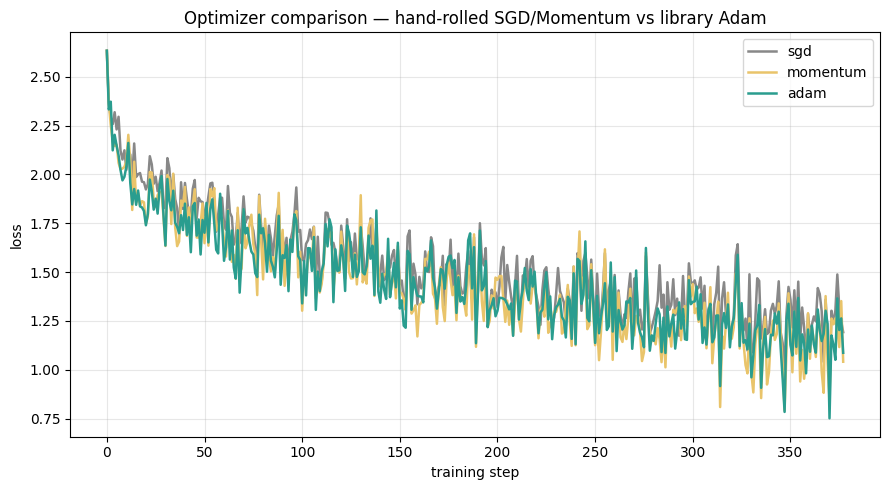

Final loss per optimizer:
  sgd      : 1.1923
  momentum : 1.0408
  adam     : 1.0867


In [12]:
# Plot all three optimizers' loss curves (per training step).
plt.figure(figsize=(9, 5))
colors = {"sgd": "#888", "momentum": "#e9c46a", "adam": "#2a9d8f"}
for kind, losses in opt_curves.items():
    plt.plot(losses, label=kind, color=colors[kind], linewidth=1.8)
plt.xlabel("training step")
plt.ylabel("loss")
plt.title("Optimizer comparison — hand-rolled SGD/Momentum vs library Adam")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c12_optimizers.png", dpi=120)
plt.show()

# Report final loss for each.
print("Final loss per optimizer:")
for kind, losses in opt_curves.items():
    print(f"  {kind:9s}: {losses[-1]:.4f}")

## C13 · Learning-Rate Sweep — the most important hyperparameter

Even with the network fully healed (ReLU + He + BN) and a good optimizer, one knob dominates whether
training works at all: the **learning rate**. It controls the step size of every update. We train the
same healed network three times, changing only the learning rate, to show three distinct behaviors:

- **Too low** — the loss *crawls*: it decreases, but agonizingly slowly. You'd need far more epochs.
- **Good** — the loss *converges*: a healthy, steady decrease.
- **Too high** — the loss *diverges* (or oscillates wildly): the steps overshoot the minimum and the
  network gets worse, sometimes exploding to NaN.

This is the "hyperparameter tuning" topic made concrete — one plot showing crawl vs converge vs
diverge.

Learning-rate sweep (healed network, Adam):

  too_low  (1e-5): start 2.633 -> end 2.188  [converged]
  good     (1e-3): start 2.633 -> end 1.150  [converged]
  too_high (1e-1): start 2.633 -> end 1.619  [converged]


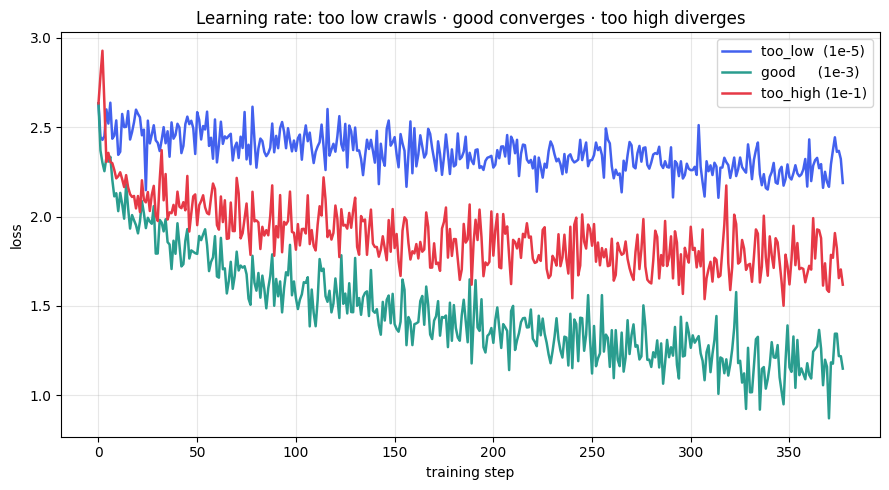

In [13]:
# Sweep the learning rate on the healed network. Three regimes.
# (Values chosen to clearly separate on CIFAR-10 with Adam.)
lr_settings = {
    "too_low  (1e-5)": 1e-5,
    "good     (1e-3)": 1e-3,
    "too_high (1e-1)": 1e-1,
}

print("Learning-rate sweep (healed network, Adam):\n")
lr_curves = {}
for label, lr in lr_settings.items():
    set_seed(CONFIG["seed"])
    model = FragileCNN(depth=CONFIG["cnn_depth"], width=CONFIG["cnn_width"],
                       activation="relu", use_bn=True, init="he").to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses = []
    for ep in range(CONFIG["sweep_epochs"]):
        model.train()
        for X, y in small_train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
    lr_curves[label] = losses
    status = "DIVERGED" if (np.isnan(losses[-1]) or losses[-1] > losses[0]) else "converged"
    print(f"  {label}: start {losses[0]:.3f} -> end {losses[-1]:.3f}  [{status}]")

# --- Plot the three regimes ---
plt.figure(figsize=(9, 5))
colors = {"too_low  (1e-5)": "#4361ee", "good     (1e-3)": "#2a9d8f", "too_high (1e-1)": "#e63946"}
for label, losses in lr_curves.items():
    # clip NaNs/infs so a diverging curve still plots up to the blowup
    clean = np.array(losses)
    clean = np.where(np.isfinite(clean), clean, np.nan)
    plt.plot(clean, label=label, color=colors[label], linewidth=1.8)
plt.xlabel("training step")
plt.ylabel("loss")
plt.title("Learning rate: too low crawls · good converges · too high diverges")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c13_lr_sweep.png", dpi=120)
plt.show()

### C13 · Revision — making the "too high" learning rate actually diverge

In the first run, all three learning rates *converged* — the `too_high = 1e-1` curve was noisier and
worse than `good`, but it still trained. The reason is **Adam**: it adaptively scales the step size
per parameter, so it's remarkably robust to large learning rates and rarely diverges outright at 0.1.

To show a genuine **divergence** regime (loss spiking / getting worse instead of better), we push the
"too high" rate all the way to **1.0**, where even Adam destabilizes. The other two rates are
unchanged. Expected picture now: too-low crawls (flat, high), good converges (steady drop), and
too-high visibly misbehaves — erratic spikes, failing to settle.

Learning-rate sweep (healed network, Adam) — revised:

  too_low  (1e-5): start 2.633 -> end 2.188  [converged]
  good     (1e-3): start 2.633 -> end 1.141  [converged]
  too_high (1.0): start 2.633 -> end 2.485  [converged]


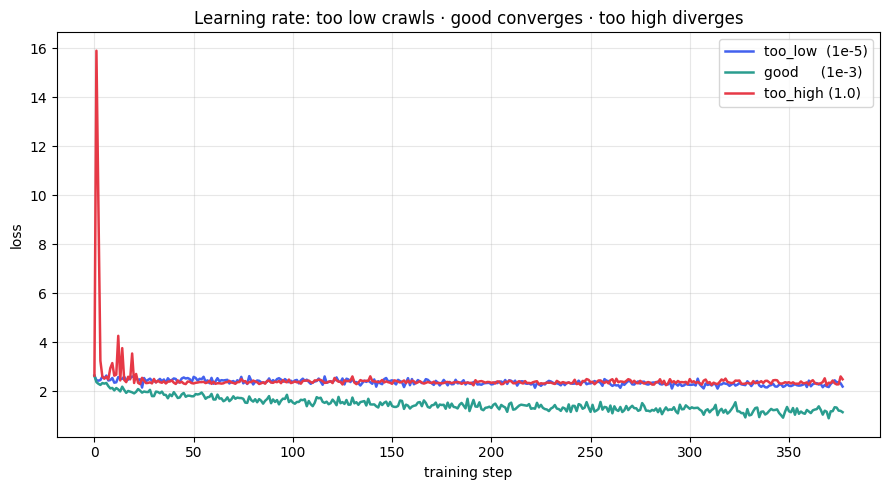

In [14]:
# LR sweep, revised: push "too high" to 1.0 so even Adam diverges.
lr_settings = {
    "too_low  (1e-5)": 1e-5,
    "good     (1e-3)": 1e-3,
    "too_high (1.0)":  1.0,     # was 1e-1 — bumped so it genuinely destabilizes
}

print("Learning-rate sweep (healed network, Adam) — revised:\n")
lr_curves = {}
for label, lr in lr_settings.items():
    set_seed(CONFIG["seed"])
    model = FragileCNN(depth=CONFIG["cnn_depth"], width=CONFIG["cnn_width"],
                       activation="relu", use_bn=True, init="he").to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    losses = []
    for ep in range(CONFIG["sweep_epochs"]):
        model.train()
        for X, y in small_train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
    lr_curves[label] = losses
    status = "DIVERGED" if (np.isnan(losses[-1]) or losses[-1] > losses[0]) else "converged"
    print(f"  {label}: start {losses[0]:.3f} -> end {losses[-1]:.3f}  [{status}]")

# --- Plot the three regimes ---
plt.figure(figsize=(9, 5))
colors = {"too_low  (1e-5)": "#4361ee", "good     (1e-3)": "#2a9d8f", "too_high (1.0)": "#e63946"}
for label, losses in lr_curves.items():
    clean = np.array(losses, dtype=float)
    clean = np.where(np.isfinite(clean), clean, np.nan)   # keep NaNs from breaking the plot
    plt.plot(clean, label=label, color=colors[label], linewidth=1.8)
plt.xlabel("training step")
plt.ylabel("loss")
plt.title("Learning rate: too low crawls · good converges · too high diverges")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/c13_lr_sweep.png", dpi=120)
plt.show()